In [67]:
import random
import logging
import numpy as np
import os
import glob
import re
import nibabel as nib
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import copy
from tqdm.auto import tqdm
import itertools
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import pickle
from osl_dynamics.data import Data
from osl_dynamics.data import processing
from osl_dynamics.models.hmm import Config
from osl_dynamics.models.hmm import Model
from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes

In [68]:
random.seed(42)
np.random.seed(42)

# Prepare Data

In [69]:
# Silence unnecessary messages
_logger = logging.getLogger("osl-dynamics")
_logger.setLevel(logging.CRITICAL + 1)

In [70]:
# Load data
data_path = '../../CIMT_data/no_wm/stim data timepoint by roi and z scored along roi dimension no white matter' # task fMRI
# data_path = '/Users/fei/Downloads/stim data time series csv organized not z scored no white matter'
X = []
y = []

for subj in sorted(os.listdir(data_path)):
    if subj != '.DS_Store':
        tc = glob.glob(f'{data_path}/*.csv')[0]
        X.append(np.loadtxt(tc, delimiter=','))
        y.append(subj[:12])

X = np.array(X) # X.shape = (subjects, timepoints, ROIs)
y = np.array(y)
print(X.shape)
print(y.shape)

(114, 250, 114)
(114,)


In [80]:
data_path = '/Users/fei/Downloads/stim data time series csv organized not z scored no white matter'
X_ = []
y_ = []

for subj in sorted(os.listdir(data_path)):
    if subj != '.DS_Store':
        tc = glob.glob(f'{data_path}/*.csv')[0]
        X_.append(np.loadtxt(tc, delimiter=','))
        y_.append(subj[:12])

X_ = np.array(X_) # X.shape = (subjects, timepoints, ROIs)
y_ = np.array(y_)
print(X_.shape)
print(y_.shape)

(114, 250, 114)
(114,)


In [92]:
for subj in range(X.shape[0]):
    print(np.min(np.mean(X[subj, :, :], axis=0)), np.max(np.mean(X[subj, :, :], axis=0)))
    print(np.min(np.std(X[subj, :, :], axis=0)), np.max(np.std(X[subj, :, :], axis=0)))

-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.088085839437099e-14 6.977396438401228e-14
0.9999999999999996 1.0000000000000004
-9.0

In [93]:
for subj in range(X_.shape[0]):
    print(np.min(np.mean(X_[subj, :, :], axis=0)), np.max(np.mean(X_[subj, :, :], axis=0)))
    print(np.min(np.std(X_[subj, :, :], axis=0)), np.max(np.std(X_[subj, :, :], axis=0)))

83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.00000011920002
0.1595637433870618 0.5660520558640773
83.24721285932009 100.000

In [86]:
iter_stan = copy.deepcopy(X_)
for i in range(X_.shape[0]):
    iter_stan[i, :, :] = (iter_stan[i, :, :] - np.mean(iter_stan[i, :, :], axis=0)) / np.std(iter_stan[i, :, :], axis=0)

vector_stan = copy.deepcopy(X_)
vector_stan = (vector_stan - np.mean(vector_stan, axis=1, keepdims=True)) / np.std(vector_stan, axis=1, keepdims=True)

np.all(iter_stan == vector_stan)

np.True_

In [94]:
for subj in range(vector_stan.shape[0]):
    print(np.min(np.mean(vector_stan[subj, :, :], axis=0)), np.max(np.mean(vector_stan[subj, :, :], axis=0)))
    print(np.min(np.std(vector_stan[subj, :, :], axis=0)), np.max(np.std(vector_stan[subj, :, :], axis=0)))

-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.000000000000001
-3.3333469318108653e-13 3.9842529275802007e-13
0.9999999999999993 1.00000000

In [6]:
# data_path = '../../CIMT_data/full/ICA/forelimb_stim_14c'
# with open(data_path + '/' + data_path.split('/')[-1] + 'SelectedDataFolders.txt', 'r') as f:
#     subj_order = f.readlines()

# bad_ICs = [1, 2] 
# X = []
# y = []
# i = 0
# for tc in sorted(os.listdir(data_path)):
#     if re.search(r"[0-9]_timecourses_ica_s1_.nii$", tc):
#         # X.append(np.loadtxt(os.path.join(data_path, tc), delimiter=','))
#         nii = nib.load(os.path.join(data_path, tc))
#         X.append(nii.get_fdata())
#         y.append(subj_order[i][-12:-8] + subj_order[i][-4:-1])
#         i += 1

# X = np.array(X) # X.shape = (subjects, timepoints, ROIs)
# X = np.delete(X, obj=[IC - 1 for IC in bad_ICs], axis=2)
# y = np.array(y)
# print(X.shape)
# print(y.shape)

(69, 250, 12)
(69,)


In [ ]:
X

In [7]:
print(X[0].shape)
print(np.prod(X[0].shape)) # n_samples = timepoints * subjects

(250, 12)
3000


In [8]:
np.unique(y)

array(['CCI_07d', 'CCI_21d', 'CCI_49d', 'SHM_07d', 'SHM_21d', 'SHM_49d'],
      dtype='<U7')

In [9]:
full_data = Data(X)
print(full_data)

Loading files:   0%|          | 0/69 [00:00<?, ?it/s]

Data
 id: 12977110480
 n_sessions: 69
 n_samples: 17250
 n_channels: 12


In [10]:
full_data.prepare({
    # "pca": {"n_pca_components": n_pca_components},
    "standardize": {},
})

Standardize:   0%|          | 0/69 [00:00<?, ?it/s]

# Create Folds

In [12]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits)

In [13]:
split_plan = {
    'outer_train': [],
    'outer_test': [],
    'inner_train': [],
    'inner_val': [],
}

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"Fold {i + 1}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    outer_train, outer_test, y_train, y_test = X[train_index,], X[test_index,], y[train_index,], y[test_index,]
    
    # # Check for even splits within groups  
    # print(np.sum(y_test == "CCI_CIMT_07d") / np.sum(y == "CCI_CIMT_07d"))
    # print(np.sum(y_test == "CCI_CIMT_21d") / np.sum(y == "CCI_CIMT_21d"))
    # print(np.sum(y_test == "CCI_CIMT_49d") / np.sum(y == "CCI_CIMT_49d"))
    # print(np.sum(y_test == "CCI_none_07d") / np.sum(y == "CCI_none_07d"))
    # print(np.sum(y_test == "CCI_none_21d") / np.sum(y == "CCI_none_21d"))
    # print(np.sum(y_test == "CCI_none_49d") / np.sum(y == "CCI_none_49d"))
    # print(np.sum(y_test == "SHM_none_07d") / np.sum(y == "SHM_none_07d"))
    # print(np.sum(y_test == "SHM_none_21d") / np.sum(y == "SHM_none_21d"))
    # print(np.sum(y_test == "SHM_none_49d") / np.sum(y == "SHM_none_49d"))
    
    inner_train, inner_val, y_inner_train, y_inner_val = train_test_split(outer_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    
    outer_train = Data(outer_train)
    outer_test = Data(outer_test)
    inner_train = Data(inner_train)
    inner_val = Data(inner_val)
    
    outer_train.prepare({
        # "pca": {"n_pca_components": n_pca_components},
        "standardize": {},
    })
    outer_test.prepare({
        # "pca": {"pca_components": outer_train.pca_components},
        "standardize": {},
    })
    outer_test = outer_test.dataset(sequence_length=250, batch_size=outer_test.n_sessions) # ensure consistent evaluation across models of different sequence_length

    inner_train.prepare({
        # "pca": {"n_pca_components": n_pca_components},
        "standardize": {},
    })
    inner_val.prepare({
        # "pca": {"pca_components": inner_train.pca_components},
        "standardize": {},
    })

    split_plan['outer_train'].append(outer_train)
    split_plan['outer_test'].append(outer_test)
    split_plan['inner_train'].append(inner_train)
    split_plan['inner_val'].append(inner_val)

Fold 1:
  Train: index=[ 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32
 33 34 35 36 37 38 39 40 41 42 43 44 50 51 52 53 54 55 56 57 58 59 60 61
 62 63 64 65 66 67 68]
  Test:  index=[ 0  1  2  3  4  5  6  7  8 45 46 47 48 49]


Loading files:   0%|          | 0/55 [00:00<?, ?it/s]

Loading files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading files:   0%|          | 0/44 [00:00<?, ?it/s]

Loading files:   0%|          | 0/11 [00:00<?, ?it/s]

...

Loading files:   0%|          | 0/12 [00:00<?, ?it/s]

Standardize:   0%|          | 0/56 [00:00<?, ?it/s]

Standardize:   0%|          | 0/13 [00:00<?, ?it/s]

Standardize:   0%|          | 0/44 [00:00<?, ?it/s]

Standardize:   0%|          | 0/12 [00:00<?, ?it/s]

# HMM Training

In [14]:
def get_param_combinations(param_grid):
    combinations = itertools.product(*param_grid.values())
    return [dict(zip(param_grid.keys(), combination)) for combination in combinations]

In [15]:
def rank_runs(log):
    return sorted(list(zip(log['params'], log['history'])), key=lambda trial: min(trial[1]['val_loss'])) # rank in increasing order of minimum val_loss

In [16]:
full_data.recommend_model_config()

Recommendation:
  config = Config(
      ...
      sequence_length=200,
      batch_size=17,
      learning_rate=0.01,
      n_epochs=20,
  )
Total number of sequences: 69
Total number of batches/parameter updates: 5


In [ ]:
# full_data_full_seq = copy.deepcopy(full_data) # just in case .dataset() modifies original data
# full_data_full_seq = full_data_full_seq.dataset(sequence_length=250, batch_size=full_data_full_seq.n_sessions) # ensure consistent evaluation across models of different sequence_length

In [18]:
param_grid_no_TDE = {
    'sequence_length': [250],
    'batch_size': [17],
    'learning_rate': [0.01], 
    'n_epochs': [20, 30, 40, 50, 60, 70], # added more options to check for possible further improvement past 20 epochs
}

In [19]:
hyperparam_CV_no_TDE = {}

In [20]:
pkl_name = "hyperparam_CV_no_TDE"

In [21]:
# # ONLY RUN IF DOESN'T ALREADY EXIST
# os.makedirs('grid_search')

In [22]:
if os.path.exists(f'grid_search/{pkl_name}.pkl'):
    with open(f'grid_search/{pkl_name}.pkl', 'rb') as f:
        hyperparam_CV_no_TDE = pickle.load(f)
    
sorted(hyperparam_CV_no_TDE.keys())

[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [23]:
hyperparam_CV_log = hyperparam_CV_no_TDE

In [23]:
# CV to determine optimal hyperparameters for each number of states n
min_n_states = 15 # must be >= 2
max_n_states = 20
param_grid = param_grid_no_TDE
for n in range(min_n_states, max_n_states + 1):
    print(f"\nGrid searching with {n} states...")
    if n not in hyperparam_CV_log:
        hyperparam_CV_log[n] = {
            'params': [], # {params}
            'histories': [], # [history object for each fold]
            'test_evidences': [], # float
        }

    i = 1
    for params in get_param_combinations(param_grid):
        print(f"Param set {i}: {params}")
        histories = []
        test_evidences = []
        for f in range(n_splits):
            print(f"\nFold {f + 1}...")
            outer_test, inner_train, inner_val = split_plan['outer_test'][f], split_plan['inner_train'][f], split_plan['inner_val'][f]
        
            config = Config(
                n_states=n,
                n_channels=inner_train.n_channels,
                sequence_length=params['sequence_length'],
                learn_means=False,
                learn_covariances=True,
                batch_size=params['batch_size'],
                learning_rate=params['learning_rate'],
                n_epochs=params['n_epochs'],
                loss_calc='mean', # to get the average per-timepoint log likelihood when computing test evidence
            )
        
            model = Model(config)
            model.random_state_time_course_initialization(inner_train, n_epochs=1, n_init=3, verbose=0)
            callback = EarlyStopping(monitor='val_loss', patience=5, verbose=0) # we don't need restore_best_weights=True because we aren't saving the models
            history = model.fit(
                inner_train,
                validation_data=inner_val.dataset(
                    sequence_length=params['sequence_length'],
                    batch_size=params['batch_size'],
                ),
                verbose=0,
                callbacks=[callback],
            )
            histories.append(history)
                
            test_evidence = model.evidence(outer_test)
            test_evidences.append(test_evidence) 

        hyperparam_CV_log[n]['params'].append(params)
        hyperparam_CV_log[n]['histories'].append(histories)
        hyperparam_CV_log[n]['test_evidences'].append(test_evidences) # can take the mean across folds later

        i += 1

    with open(f'grid_search/{pkl_name}.pkl', 'wb') as f:
        pickle.dump(hyperparam_CV_log, f)


Grid searching with 15 states...
Param set 1: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 20}

Fold 1...


2025-11-02 09:03:47.036386: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-02 09:03:50.256959: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2025-11-02 09:03:59 WARNING tensorflow [polymorphic_function.py:157:called_with_tracing]: 5 out of the last 13 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x32b742160> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


Getting evidence; Test data sequence length: 250:   0%|          | 0/1 [00:00<?, ?it/s]

2025-11-02 09:04:31.221256: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Getting evidence; Test data sequence length: 250:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 4...


Getting evidence; Test data sequence length: 250:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 5...


Getting evidence; Test data sequence length: 250:   0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
sorted_states = sorted(hyperparam_CV_log.keys())
sorted_states

[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

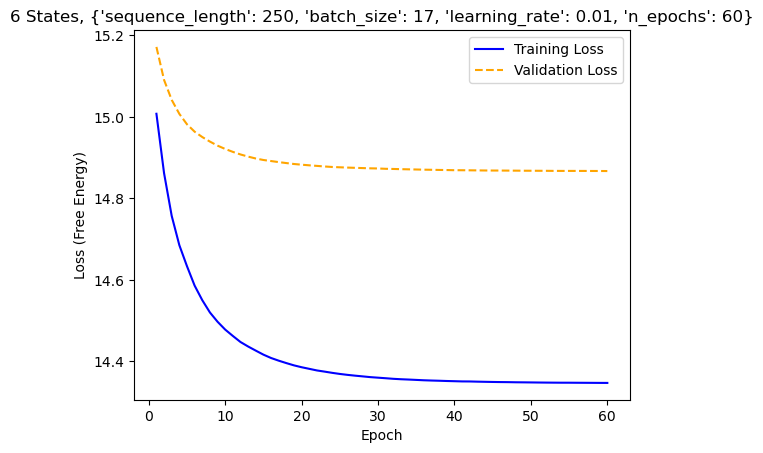

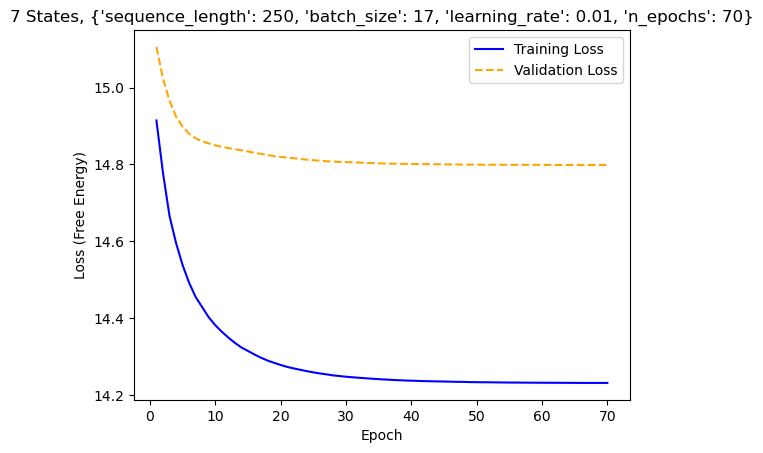

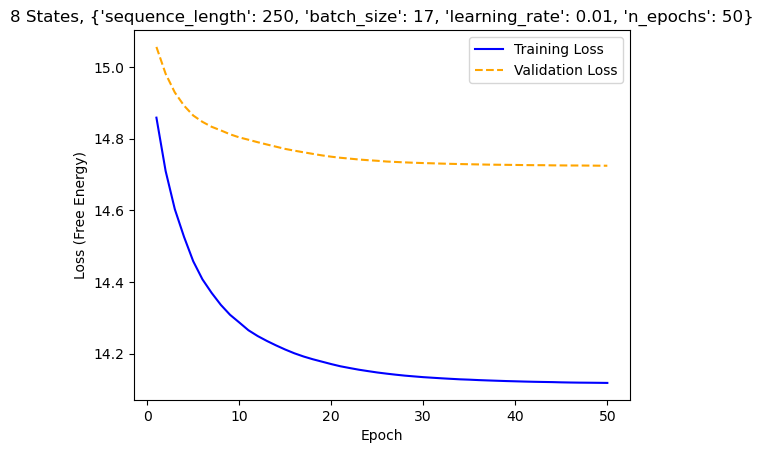

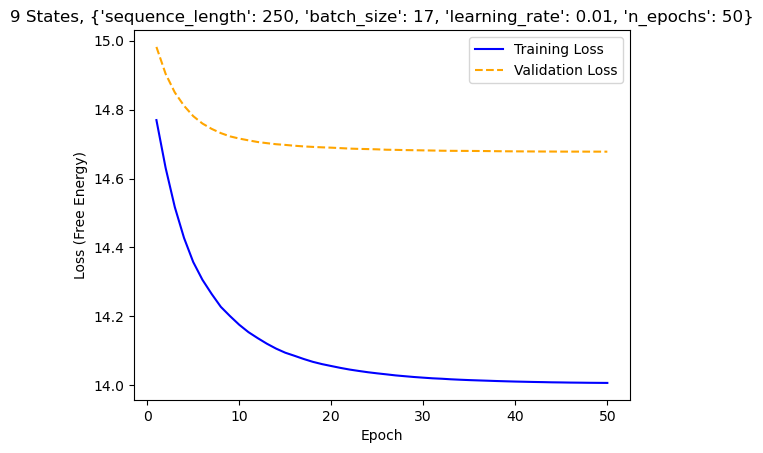

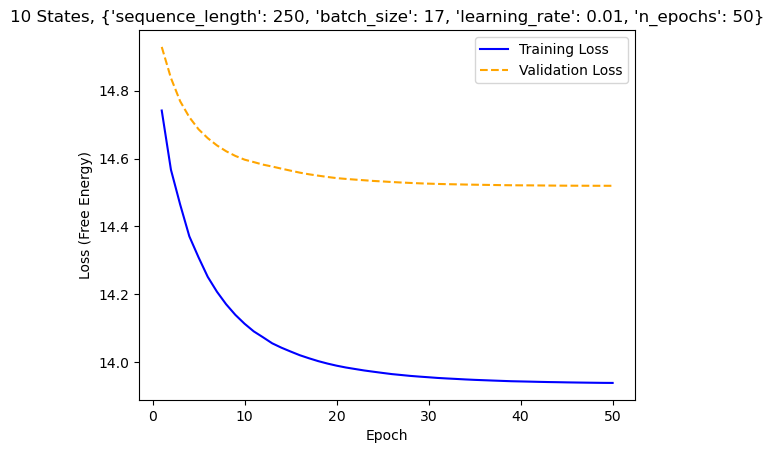

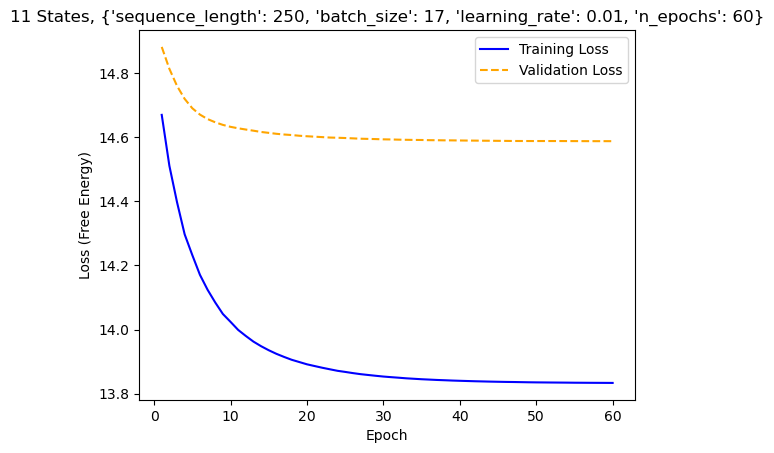

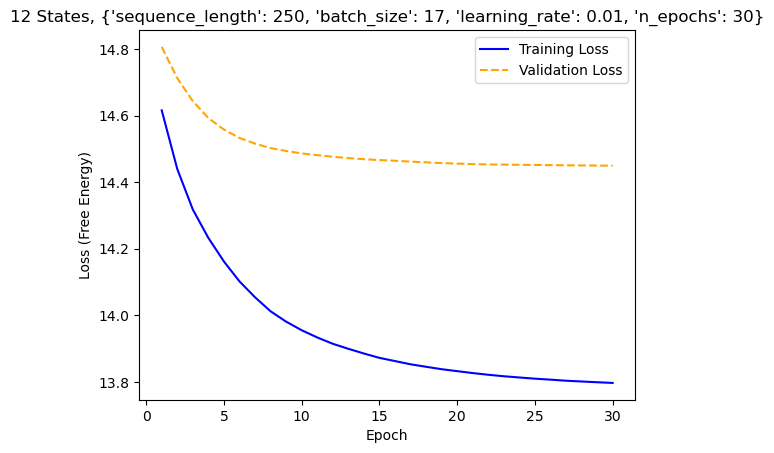

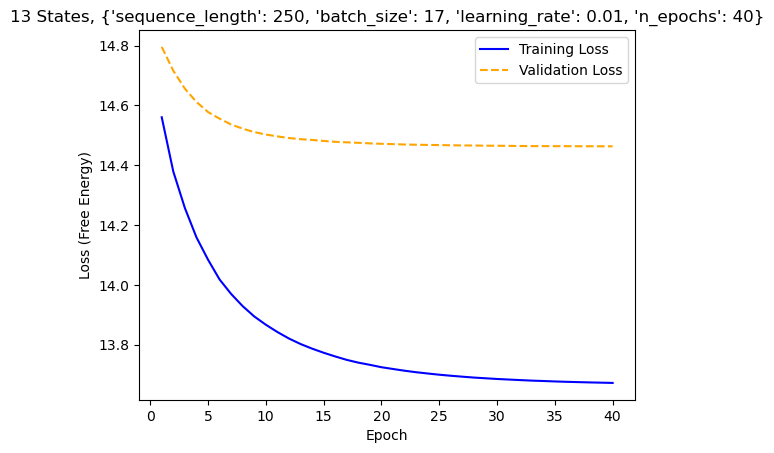

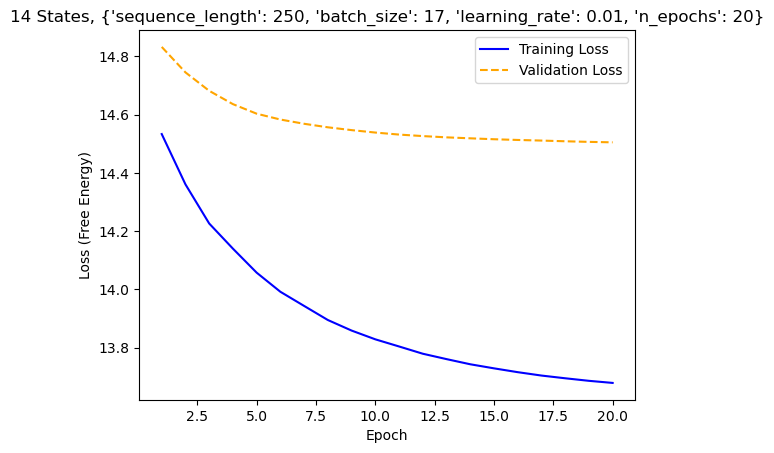

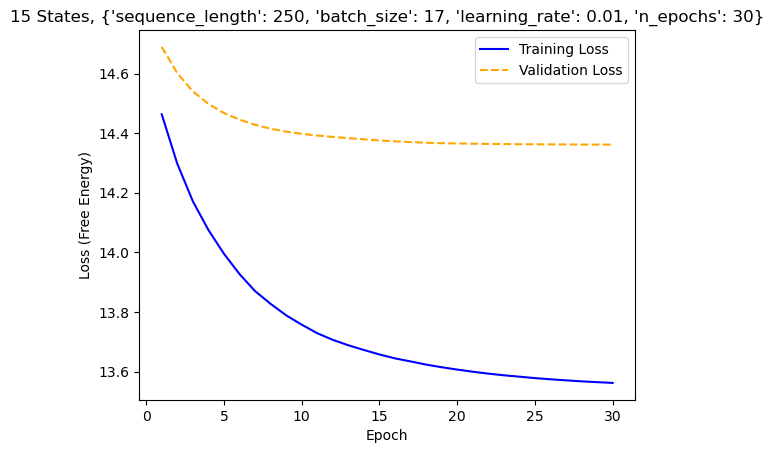

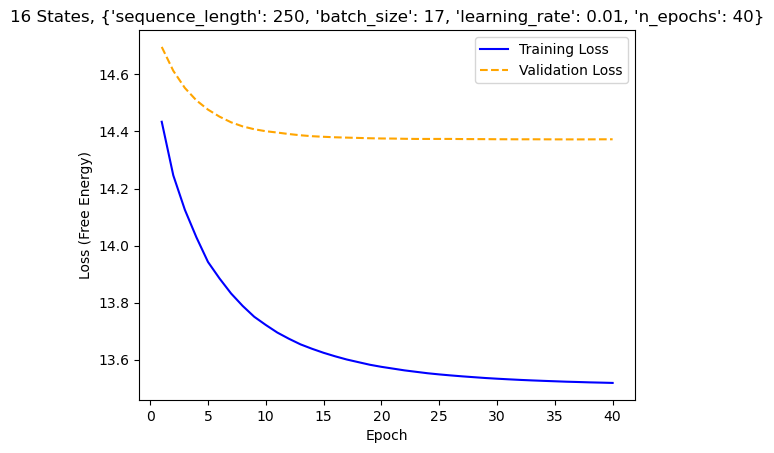

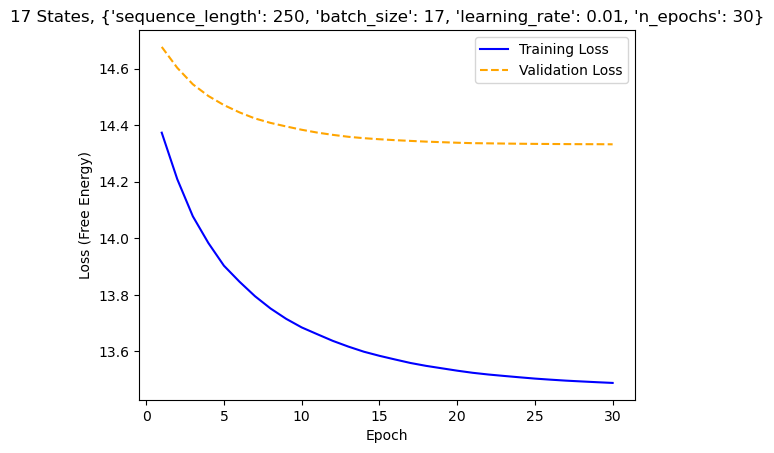

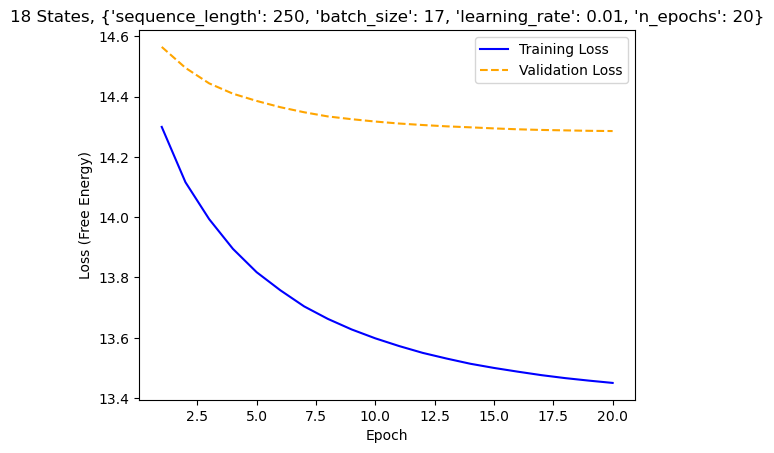

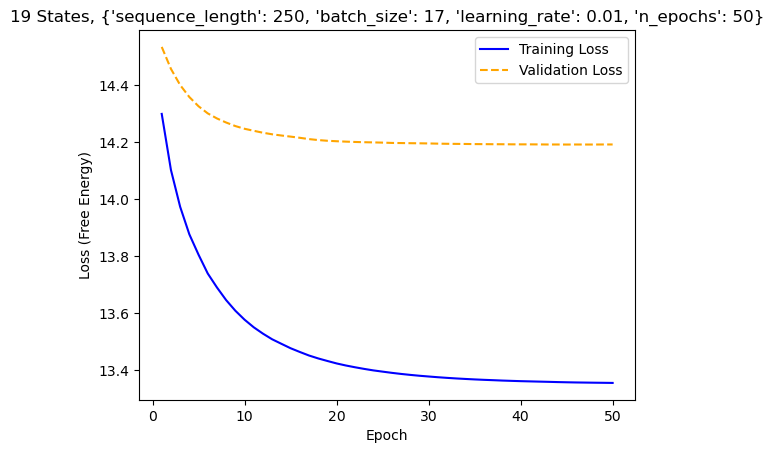

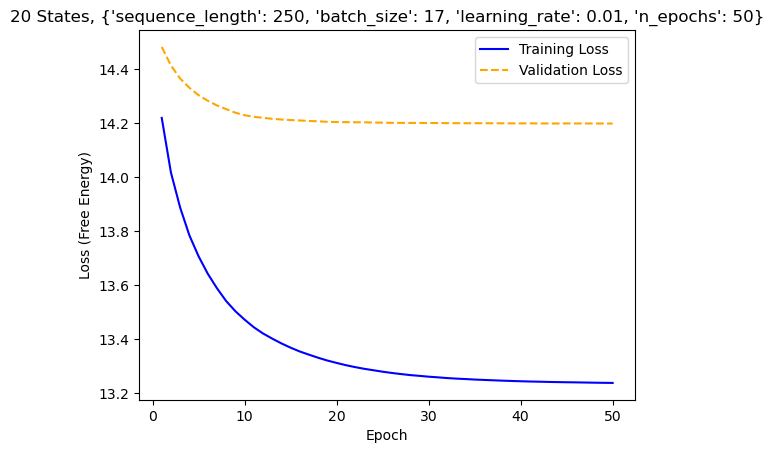

In [25]:
# Sanity check
f_idx = 0
for n in sorted_states:
    example = hyperparam_CV_log[n]['histories'][np.argmax(np.mean(hyperparam_CV_log[n]['test_evidences'], axis=1))]
    fig, ax = plt.subplots(1, 1)
    x = range(1, len(example[f_idx]['loss']) + 1)
    ax.plot(x, example[f_idx]['loss'], label="Training Loss", color='blue', linestyle='-')
    ax.plot(x, example[f_idx]['val_loss'], label="Validation Loss", color='orange', linestyle='--')

    ax.set_title(f"{n} States, " + str(hyperparam_CV_log[n]['params'][np.argmax(np.mean(hyperparam_CV_log[n]['test_evidences'], axis=1))]))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (Free Energy)")
    ax.legend()
    plt.show()

In [26]:
with open(f'grid_search/{pkl_name}.pkl', 'wb') as f:
    pickle.dump(hyperparam_CV_log, f)

In [26]:
for n in sorted_states:
    print(f"Best params for {n} states: {hyperparam_CV_log[n]['params'][np.argmax(np.mean(hyperparam_CV_log[n]['test_evidences'], axis=1))]}")

Best params for 6 states: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 60}
Best params for 7 states: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 70}
Best params for 8 states: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 50}
Best params for 9 states: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 50}
Best params for 10 states: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 50}
Best params for 11 states: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 60}
Best params for 12 states: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 30}
Best params for 13 states: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 40}
Best params for 14 states: {'sequence_length': 250, 'batch_size': 17, 'learning_rate': 0.01, 'n_epochs': 20}
Best params for 15 stat

In [29]:
iters = 5

In [29]:
# Compute full-dataset evaluation metrics
for n in sorted_states:
    print(f"Fitting model with {n} states...")
    hyperparam_CV_log[n]['full_evidence'] = []
    hyperparam_CV_log[n]['BIC'] = []
    # hyperparam_CV_log[n]['ICL'] = []
    for i in range(iters): # account for variability in .random_state_time_course_initialization(), then average later
        print(f"Iteration {i + 1}:")
        best_params = hyperparam_CV_log[n]['params'][np.argmax(np.mean(hyperparam_CV_log[n]['test_evidences'], axis=1))]
        config = Config(
            n_states=n,
            n_channels=full_data.n_channels,
            sequence_length=best_params['sequence_length'],
            learn_means=False,
            learn_covariances=True,
            batch_size=best_params['batch_size'],
            learning_rate=best_params['learning_rate'],
            n_epochs=best_params['n_epochs'],
            loss_calc='mean', # to get the average per-timepoint log likelihood when computing test evidence
        )
        
        model = Model(config)
        model.random_state_time_course_initialization(full_data, n_epochs=1, n_init=3, verbose=0)
        history = model.fit(full_data, verbose=0)
    
        mean_per_timepoint_LL = model.evidence(full_data_full_seq)
        hyperparam_CV_log[n]['full_evidence'].append(mean_per_timepoint_LL)
    
        # Compute BIC
        total_LL = mean_per_timepoint_LL * full_data.n_samples
        d = full_data.n_channels
        k = (n - 1) + n * (n - 1) + n * (d + (d * (d + 1)) / 2) # number of estimated parameters
        BIC = k * np.log(full_data.n_samples) - 2 * total_LL
        hyperparam_CV_log[n]['BIC'].append(BIC)
    
        # # Compute ICL (integrated completed likelihood)
        # pred_data = copy.deepcopy(full_data)
        # pred_data = pred_data.dataset(sequence_length=model.config.sequence_length, batch_size=full_data.n_sessions)
        # entropies = []
        # for batch in tqdm(pred_data, desc="Computing posterior entropy..."):
        #     pred = model.predict(batch, verbose=0)
        #     entropy = model.get_posterior_entropy(pred['gamma'], pred['xi']) 
        #     entropies.append(entropy)
            
        # posterior_entropy = np.mean(entropies) * full_data.n_samples
        # ICL = BIC + 2 * posterior_entropy # add because .get_posterior_entropy() technically returns the negative posterior entropy
        # hyperparam_CV_log[n]['ICL'].append(ICL)

    with open(f'grid_search/{pkl_name}.pkl', 'wb') as f:
        pickle.dump(hyperparam_CV_no_TDE, f)

Fitting model with 6 states...
Iteration 1:


Getting evidence; Test data sequence length: 250:   0%|          | 0/1 [00:00<?, ?it/s]

Computing posterior entropy...:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration 2:


Getting evidence; Test data sequence length: 250:   0%|          | 0/1 [00:00<?, ?it/s]

...

Getting evidence; Test data sequence length: 250:   0%|          | 0/1 [00:00<?, ?it/s]

Computing posterior entropy...:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration 5:


Getting evidence; Test data sequence length: 250:   0%|          | 0/1 [00:00<?, ?it/s]

Computing posterior entropy...:   0%|          | 0/1 [00:00<?, ?it/s]

In [30]:
with open(f'grid_search/{pkl_name}.pkl', 'wb') as f:
    pickle.dump(hyperparam_CV_no_TDE, f)

In [34]:
metric = 'full_evidence'
# metric = 'BIC'
one_se_rule = {}

for key, value in hyperparam_CV_log.items():
    one_se_rule[key] = {
        'mean': np.mean(value[metric]),
        'se': np.std(value[metric], ddof=1) / np.sqrt(iters),
    }

In [35]:
sorted_by_mean = sorted(list(one_se_rule.items()), key=lambda x: x[1]['mean'])
sorted_by_mean

[(6, {'mean': np.float32(-14.78335), 'se': np.float64(0.01739711826391726)}),
 (7, {'mean': np.float32(-14.69368), 'se': np.float64(0.010307236689489603)}),
 (8, {'mean': np.float32(-14.6462), 'se': np.float64(0.012053161864629184)}),
 (9, {'mean': np.float32(-14.544016), 'se': np.float64(0.005524650393618418)}),
 (10,
  {'mean': np.float32(-14.503673), 'se': np.float64(0.002355531614875652)}),
 (11,
  {'mean': np.float32(-14.452356), 'se': np.float64(0.007539982422043816)}),
 (12,
  {'mean': np.float32(-14.391327), 'se': np.float64(0.014362335142213948)}),
 (13,
  {'mean': np.float32(-14.347055), 'se': np.float64(0.007627880606770121)}),
 (14,
  {'mean': np.float32(-14.310313), 'se': np.float64(0.015166733480496188)}),
 (15,
  {'mean': np.float32(-14.254886), 'se': np.float64(0.006398423906916326)}),
 (16,
  {'mean': np.float32(-14.190834), 'se': np.float64(0.006742734557773048)}),
 (17,
  {'mean': np.float32(-14.175394), 'se': np.float64(0.008025862295724839)}),
 (18,
  {'mean': np.f

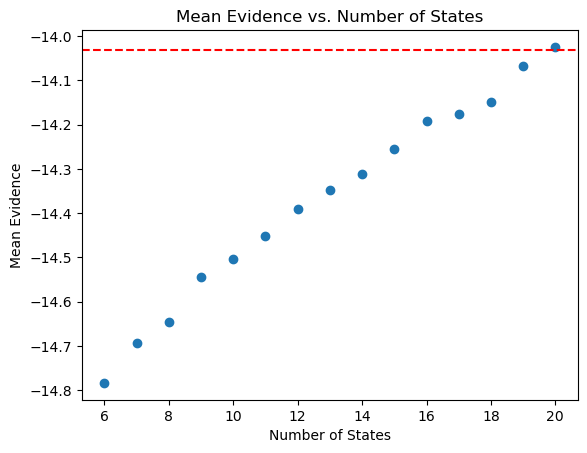

In [36]:
fig, ax = plt.subplots(1, 1)
n_states = [x[0] for x in sorted_by_mean]
means = [x[1]['mean'] for x in sorted_by_mean]
ax.scatter(n_states, means)
if metric == 'full_evidence':
    ax.axhline(y=sorted_by_mean[-1][1]['mean'] - sorted_by_mean[-1][1]['se'], color='r', linestyle='--')
    ax.set_title("Mean Evidence vs. Number of States")
    ax.set_xlabel("Number of States")
    ax.set_ylabel("Mean Evidence")
else:
    ax.axhline(y=sorted_by_mean[0][1]['mean'] + sorted_by_mean[0][1]['se'], color='r', linestyle='--')
    ax.set_title("Mean BIC vs. Number of States")
    ax.set_xlabel("Number of States")
    ax.set_ylabel("Mean BIC")

In [37]:
print(f"Number of states: {metric}")
for n in sorted_states:
    print(f"{n}: {np.mean(hyperparam_CV_no_TDE[n][metric])}")

Number of states: full_evidence
6: -14.783349990844727
7: -14.693679809570312
8: -14.646200180053711
9: -14.544015884399414
10: -14.50367259979248
11: -14.452356338500977
12: -14.391326904296875
13: -14.347055435180664
14: -14.31031322479248
15: -14.25488567352295
16: -14.190834045410156
17: -14.175394058227539
18: -14.14856243133545
19: -14.066619873046875
20: -14.024319648742676


In [ ]:
# "Empirically, we find picking the best run from a set of 10 consistently finds the same set of model parameters."

In [221]:
def realization_corr(r1, r2):
    r1_stan = (r1 - np.mean(r1, axis=0, keepdims=True)) / np.std(r1, axis=0, keepdims=True)
    r2_stan = (r2 - np.mean(r2, axis=0, keepdims=True)) / np.std(r2, axis=0, keepdims=True)

    return r1_stan.T @ r2_stan / (r1_stan.shape[0] - 1)

In [270]:
num_states = 6
num_realizations = 3
realizations = []
for r in range(num_realizations):
    realizations.append({})
    best_params = hyperparam_CV_log[num_states]['params'][np.argmax(np.mean(hyperparam_CV_log[num_states]['test_evidences'], axis=1))]
        
    config = Config(
        n_states=num_states,
        n_channels=full_data.n_channels,
        sequence_length=best_params['sequence_length'],
        learn_means=False,
        learn_covariances=True,
        batch_size=best_params['batch_size'],
        learning_rate=best_params['learning_rate'],
        n_epochs=best_params['n_epochs'],
    )
        
    model = Model(config)
    model.random_state_time_course_initialization(full_data, n_epochs=1, n_init=3, verbose=0)
    history = model.fit(full_data, verbose=0)
    
    _, covs = model.get_means_covariances()
    realizations[r]['covs'] = covs

    off_diags = []
    for cov in covs:
        ut = np.triu(cov, k=1) # upper triange, excluding main diagonal
        off_diag = ut[ut != 0]
        off_diags.append(off_diag)

    realizations[r]['off_diags'] = np.array(off_diags).T

2025-11-10 15:30:08.461311: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [271]:
CRCM = np.zeros(shape=(num_states * num_realizations, num_states * num_realizations))

In [272]:
# FIGURE OUT WHETHER TO TAKE ABSOLUTE VALUES OF CORRELATIONS!!!
for i in range(len(realizations)):
    for j in range(len(realizations)):
        if i != j:
            CRCM[i * num_states:(i * num_states) + num_states, j * num_states:(j * num_states) + num_states] = realization_corr(realizations[i]['off_diags'], realizations[j]['off_diags'])

In [273]:
print(CRCM.shape)
# print(np.round(CRCM, 1))

(18, 18)


In [274]:
CRCM_temp = copy.deepcopy(CRCM)
state_groups = [] # [(realization number, state number), ...] using 1-based indexing for realization and state numbers for interpretability
while np.max(CRCM_temp) > 0:
    state_groups.append([])
    m, n = np.unravel_index(np.argmax(CRCM_temp), shape=CRCM.shape)
    state_groups[-1].append((int(m // num_states + 1), int(m % num_states + 1)))
    state_groups[-1].append((int(n // num_states + 1), int(n % num_states + 1)))
    for i in range(num_realizations):
        if i != m // num_states and i != n // num_states:
            p_i = i * num_states + np.argmax(CRCM_temp[m, i * num_states:(i * num_states) + num_states])
            q_i = i * num_states + np.argmax(CRCM_temp[i * num_states:(i * num_states) + num_states, n])
            if p_i == q_i or CRCM_temp[m, p_i] > CRCM_temp[q_i, n]:
                state_groups[-1].append((i + 1, int(p_i % num_states + 1)))
                CRCM_temp[:, p_i] = 0
                CRCM_temp[p_i, :] = 0
            else:
                state_groups[-1].append((i + 1, int(q_i % num_states + 1)))
                CRCM_temp[q_i, :] = 0
                CRCM_temp[:, q_i] = 0

    CRCM_temp[m, :] = 0
    CRCM_temp[:, m] = 0
    CRCM_temp[:, n] = 0
    CRCM_temp[n, :] = 0

In [275]:
within_group_avg_corrs = []
for g in range(len(state_groups)):
    off_diags = []
    within_group_corrs = []
    for r, s in sorted(state_groups[g], key=lambda r: r[0]):
        off_diags.append(realizations[r - 1]['off_diags'][:, s - 1]) # r and s use 1-based indexing, so must subtract 1
        
    for i in range(len(off_diags)):
        for j in range(i + 1, len(off_diags)):
            within_group_corrs.append(np.corrcoef(off_diags[i], off_diags[j]))

    within_group_avg_corr = np.mean(within_group_corrs)
    within_group_avg_corrs.append(within_group_avg_corr)

In [276]:
idx_seq = []
for i, corr in sorted(enumerate(within_group_avg_corrs), key=lambda x: x[1], reverse=True):
    idx_seq.append(i)
    print(i + 1, corr)

1 0.951610671769228
2 0.9323094443933931
3 0.9162550873493269
4 0.9069181501712444
5 0.8968707926693277
6 0.8950570980848661


In [277]:
# Reorder state_groups and within_group_avg_corrs in order of decreasing average between-realization correlation
state_groups = [state_groups[i] for i in idx_seq]
within_group_avg_corrs = [within_group_avg_corrs[i] for i in idx_seq]
for g in range(len(state_groups)):
    print(f"\nAligned State {g + 1}:")
    for r, s in sorted(state_groups[g], key=lambda r: r[0]):
        print(f"Realization {r}, state {s}")

    print(f"Average between-realization correlation: {within_group_avg_corrs[g]}")


Aligned State 1:
Realization 1, state 1
Realization 2, state 3
Realization 3, state 1
Average between-realization correlation: 0.951610671769228

Aligned State 2:
Realization 1, state 2
Realization 2, state 2
Realization 3, state 2
Average between-realization correlation: 0.9323094443933931

Aligned State 3:
Realization 1, state 3
Realization 2, state 6
Realization 3, state 4
Average between-realization correlation: 0.9162550873493269

Aligned State 4:
Realization 1, state 4
Realization 2, state 5
Realization 3, state 3
Average between-realization correlation: 0.9069181501712444

Aligned State 5:
Realization 1, state 6
Realization 2, state 4
Realization 3, state 6
Average between-realization correlation: 0.8968707926693277

Aligned State 6:
Realization 1, state 5
Realization 2, state 1
Realization 3, state 5
Average between-realization correlation: 0.8950570980848661


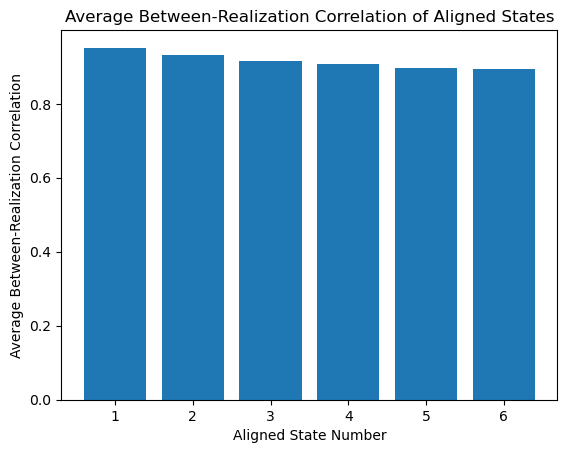

In [278]:
plt.bar(
    [str(i) for i in range(1, len(state_groups) + 1)],
    within_group_avg_corrs,
)

plt.title("Average Between-Realization Correlation of Aligned States")
plt.xlabel("Aligned State Number")
plt.ylabel("Average Between-Realization Correlation")
plt.show()